<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/03_Parallel_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(5)

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull qwen2.5:3b

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [7]:
model = ChatOllama(
    model="qwen2.5:3b",
    temperature=0
)

In [8]:
class EvaluationSchemas(BaseModel):
  feedback: str = Field(description="Detailed feedback of the essay")
  score: int = Field(description="Score of the essay out of 10", le=10, ge=0)

structured_model = model.with_structured_output(EvaluationSchemas)

In [9]:
class EvaluationState(TypedDict):
  essay: str
  language_feedback: str
  clarity_feedback: str
  analysis_feedback: str
  overall_feedback: str
  individual_score: Annotated[list[int], operator.add]
  avg_score: float


def get_language_feedback(state: EvaluationState) -> dict:

  prompt = f"Evaluate the language quality of the folloeing essay, provide a feedback and give a score out of 10 \n {state['essay']}"
  response = structured_model.invoke(prompt)

  return {'language_feedback': response.feedback, 'individual_score': [response.score]}

def get_clarity_feedback(state: EvaluationState) -> dict:

  prompt = f"Evaluate the language clarity of thought of the folloeing essay, provide a feedback and give a score out of 10 \n {state['essay']}"
  response = structured_model.invoke(prompt)

  return {'clarity_feedback': response.feedback, 'individual_score': [response.score]}


def get_analysis_feedback(state: EvaluationState) -> dict:

  prompt = f"Evaluate the language depth of analysis of the folloeing essay, provide a feedback and give a score out of 10 \n {state['essay']}"
  response = structured_model.invoke(prompt)

  return {'analysis_feedback': response.feedback, 'individual_score': [response.score]}

def get_overall_feedback(state: EvaluationState) -> dict:

  prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
  overall_feedback = model.invoke(prompt).content

  avg_score = sum(state['individual_score']) / len(state['individual_score'])

  return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [10]:
graph = StateGraph(EvaluationState)

graph.add_node("get_language_feedback", get_language_feedback)
graph.add_node("get_clarity_feedback", get_clarity_feedback)
graph.add_node("get_analysis_feedback", get_analysis_feedback)
graph.add_node("get_overall_feedback", get_overall_feedback)

graph.add_edge(START, "get_language_feedback")
graph.add_edge(START, "get_clarity_feedback")
graph.add_edge(START, "get_analysis_feedback")
graph.add_edge("get_language_feedback", "get_overall_feedback")
graph.add_edge("get_clarity_feedback", "get_overall_feedback")
graph.add_edge("get_analysis_feedback", "get_overall_feedback")
graph.add_edge("get_overall_feedback", END)

workflow = graph.compile()

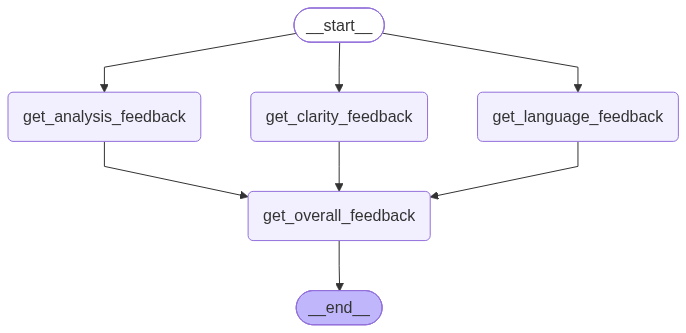

In [11]:
workflow

In [12]:
essay = """
# India: A Journey Through Timeless Travel Destinations

India is not merely a country; it is a living civilization that has evolved over thousands of years while preserving its remarkable cultural and geographical diversity. From the snow-covered peaks of the Himalayas to the sun-kissed beaches of the Indian Ocean, from ancient temples carved into stone to futuristic metropolitan skylines, India offers an unparalleled spectrum of travel experiences. Every destination in the country narrates a unique story of history, tradition, nature, and human resilience. Consequently, travelling across India is not simply about visiting places; it is about experiencing the coexistence of multiple cultures, languages, religions, cuisines, and landscapes within a single nation.

One of India's greatest strengths as a travel destination lies in its extraordinary geographical diversity. The Himalayan region in the north, encompassing states such as Jammu and Kashmir, Himachal Pradesh, Uttarakhand, and Sikkim, offers breathtaking mountain ranges, pristine lakes, alpine meadows, and adventurous trekking routes. These regions attract mountaineers, photographers, nature enthusiasts, and spiritual seekers alike. Destinations such as Leh-Ladakh provide dramatic high-altitude deserts and ancient Buddhist monasteries, while the Valley of Flowers in Uttarakhand demonstrates nature's ability to transform rugged mountains into vibrant carpets of blooming flora. Such landscapes highlight the ecological richness of India and underscore the importance of conserving fragile mountain ecosystems.

In contrast, southern India presents an entirely different yet equally captivating landscape. Kerala, often referred to as "God's Own Country," is renowned for its tranquil backwaters, lush coconut groves, Ayurvedic wellness traditions, and biodiversity-rich forests. Tamil Nadu showcases magnificent Dravidian temple architecture, with towering gopurams that represent centuries of artistic excellence and religious devotion. Karnataka seamlessly combines historical grandeur, exemplified by Hampi's magnificent ruins, with modern technological innovation in cities such as Bengaluru. These destinations collectively illustrate how natural beauty and human civilization can coexist harmoniously.

Western India reveals another fascinating dimension of the nation's tourism. Rajasthan stands as a testament to India's royal heritage, where majestic forts, opulent palaces, and vibrant desert landscapes evoke the grandeur of the Rajput kingdoms. Cities such as Jaipur, Udaipur, Jodhpur, and Jaisalmer transport visitors into an era of valor, architecture, and cultural richness. Gujarat, meanwhile, offers a remarkable blend of wildlife, spirituality, and craftsmanship. The Gir National Park protects the last remaining population of Asiatic lions, while the white salt desert of the Rann of Kutch transforms into a mesmerizing cultural festival during the annual Rann Utsav.

Eastern and northeastern India possess an equally compelling yet often underappreciated tourism potential. West Bengal seamlessly combines colonial heritage, literary traditions, and natural beauty. Kolkata, the cultural capital of India, celebrates art, literature, music, and intellectual discourse, while the Sundarbans showcase the world's largest mangrove forest and the elusive Royal Bengal Tiger. The northeastern states, collectively known as the "Seven Sisters" along with Sikkim, remain among India's most pristine travel destinations. Meghalaya's living root bridges, Arunachal Pradesh's untouched valleys, Assam's Kaziranga National Park, and Nagaland's vibrant tribal festivals provide authentic cultural experiences that distinguish the region from the rest of the country.

India's cultural and historical heritage significantly enhances its appeal as a global tourist destination. Home to numerous UNESCO World Heritage Sites, the country preserves architectural marvels that span multiple dynasties and civilizations. The Taj Mahal symbolizes eternal love and remains one of the world's most recognizable monuments. The Ajanta and Ellora caves demonstrate the extraordinary artistic achievements of ancient Indian craftsmen, while the temples of Khajuraho exhibit intricate sculptures reflecting both spirituality and human creativity. These monuments are not merely architectural achievements; they are historical documents that preserve the social, religious, and artistic evolution of Indian civilization.

Religious and spiritual tourism represents another defining characteristic of Indian travel. As the birthplace of Hinduism, Buddhism, Jainism, and Sikhism, India attracts millions of pilgrims every year. Cities such as Varanasi, Haridwar, Rishikesh, Bodh Gaya, Amritsar, and Tirupati are not only centers of worship but also repositories of philosophy, tradition, and cultural continuity. The annual Kumbh Mela, recognized as one of the largest peaceful gatherings in human history, reflects India's enduring spiritual traditions and demonstrates the deep connection between faith and social identity.

Indian cuisine further enriches the travel experience. Every region offers distinctive flavors shaped by geography, climate, and cultural influences. North India is renowned for rich curries, breads, and kebabs, while South India offers dosas, idlis, sambhar, and coconut-based delicacies. Western India presents flavorful Gujarati thalis and Rajasthani cuisine adapted to desert conditions, whereas Eastern India is celebrated for seafood, sweets such as rasgulla and sandesh, and aromatic rice dishes. Culinary exploration allows travelers to understand regional history, agricultural practices, and cultural traditions through food.

The economic significance of tourism in India extends far beyond recreation. The tourism industry generates employment across multiple sectors, including transportation, hospitality, handicrafts, local entrepreneurship, and cultural preservation. Rural tourism initiatives have empowered local communities by creating sustainable livelihoods while encouraging the conservation of indigenous traditions and ecosystems. Furthermore, eco-tourism projects promote responsible travel practices that balance economic development with environmental protection.

Despite its immense potential, India's tourism sector faces several challenges. Infrastructure disparities, overcrowding at popular destinations, environmental degradation, waste management issues, and inadequate preservation of heritage sites can diminish visitor experiences. Sustainable tourism practices, investment in infrastructure, digital accessibility, and stronger conservation policies are essential to ensuring that future generations continue to benefit from India's rich natural and cultural heritage. Responsible travelers also play a crucial role by respecting local customs, minimizing environmental impact, and supporting community-based tourism initiatives.

In conclusion, India stands as one of the world's most diverse and captivating travel destinations. Its unparalleled combination of natural beauty, historical grandeur, spiritual depth, cultural diversity, and culinary richness offers experiences that cater to every type of traveler. Whether one seeks adventure in the Himalayas, serenity in Kerala's backwaters, architectural brilliance in Rajasthan, wildlife in central India, or spiritual enlightenment along the banks of the Ganges, India provides journeys that transcend ordinary tourism. Ultimately, travelling through India is not merely about exploring a destination; it is about discovering the extraordinary complexity, resilience, and timeless spirit of one of the world's oldest civilizations.

"""

In [13]:
intial_state = {
    'essay': essay
}

result = workflow.invoke(intial_state)

In [15]:
result

{'essay': '\n# India: A Journey Through Timeless Travel Destinations\n\nIndia is not merely a country; it is a living civilization that has evolved over thousands of years while preserving its remarkable cultural and geographical diversity. From the snow-covered peaks of the Himalayas to the sun-kissed beaches of the Indian Ocean, from ancient temples carved into stone to futuristic metropolitan skylines, India offers an unparalleled spectrum of travel experiences. Every destination in the country narrates a unique story of history, tradition, nature, and human resilience. Consequently, travelling across India is not simply about visiting places; it is about experiencing the coexistence of multiple cultures, languages, religions, cuisines, and landscapes within a single nation.\n\nOne of India\'s greatest strengths as a travel destination lies in its extraordinary geographical diversity. The Himalayan region in the north, encompassing states such as Jammu and Kashmir, Himachal Pradesh,

In [16]:
essay2 = """
# Travel Destination of India

India is a very big country and there are many travel destinations in it. Many people come from different countries to visit India because it has many famous places. There are mountains, rivers, beaches, forests and many other things. People like to travel because it is enjoyable and they can see new places.

One famous place is the Taj Mahal. It is in Agra and many tourists visit it every year. It is made of white marble and looks very beautiful. There are also many temples in India. Some people go there for prayer and some people go just to see them. India has many old buildings and they are very interesting.

There are also hill stations like Shimla and Manali. These places are cold and people visit them in summer. Kashmir is also very nice because there are mountains and lakes. Kerala is famous for boats and backwaters. Goa has beaches where many people go for holidays. Rajasthan has deserts and forts. These places are different from each other, so people have many choices.

India also has different kinds of food. Every state has its own food and people enjoy eating different dishes. Festivals are also good for tourists because they can see dances, music and traditions. People in India celebrate many festivals, so tourists can enjoy them.

Tourism is good because it gives money to the country. Hotels, shops and guides get work when tourists come. If more people visit India, then the country can become more popular. The government should also make places clean because dirty places are not good for tourists.

There are some problems also. Some places are crowded and there is too much traffic. Sometimes there is pollution and garbage. It can make the travel difficult. Some roads are not good, so people face problems while travelling.

In conclusion, India is a good country for travelling. It has many famous places and different kinds of things to see. People can visit mountains, beaches, temples and cities. India is beautiful and many tourists like it. So, India is one of the best countries to travel.

"""

In [17]:
intial_state = {
    'essay': essay2
}

result2 = workflow.invoke(intial_state)

In [18]:
result2

{'essay': '\n# Travel Destination of India\n\nIndia is a very big country and there are many travel destinations in it. Many people come from different countries to visit India because it has many famous places. There are mountains, rivers, beaches, forests and many other things. People like to travel because it is enjoyable and they can see new places.\n\nOne famous place is the Taj Mahal. It is in Agra and many tourists visit it every year. It is made of white marble and looks very beautiful. There are also many temples in India. Some people go there for prayer and some people go just to see them. India has many old buildings and they are very interesting.\n\nThere are also hill stations like Shimla and Manali. These places are cold and people visit them in summer. Kashmir is also very nice because there are mountains and lakes. Kerala is famous for boats and backwaters. Goa has beaches where many people go for holidays. Rajasthan has deserts and forts. These places are different fro